# Evening Star — a quantitative teardown 🔬
### Precise OHLC detector · signed-short forward 1/5/10-day event study · a drift-neutral Welch *t* design · a coin-flip label-shuffle placebo · a Bonferroni correction across the 30-name basket · costs + borrow · strict-gap & prior-uptrend myth-checks · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Crash_incoming%3F: Busted](https://img.shields.io/badge/Crash_incoming%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The evening star is candlestick lore's marquee **bearish reversal** — the job here is to test it honestly as a short signal, with one subtlety front and centre: the basket carries the market's own positive drift, so a naive *t*-vs-zero **overstates** any apparent bearishness. Everything below is built around removing that contamination.

> ⚠️ **Data + survivorship note.** Fixed **30-name liquid large-cap + SPY** basket, names still trading in 2026 — a *survivor* panel that **excludes the firms that actually topped, crashed and delisted**, i.e. it tilts the test *toward* finding a working bearish signal. It still doesn't. Real data: yfinance daily OHLCV, `auto_adjust=True`, 2005→2026, as-of **2026-06-30**. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprints `bde089f6e8ee` / `97e1b85d26c3`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from evening_star import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real(allow_fetch=False, asof="2026-06-30")
else:
    PANEL = None
print("real basket cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-30', 'years': 21.5, 'n_names': 30, 'fp_quantlab': 'bde089f6e8ee', 'fp_basket': '97e1b85d26c3', 'total_bars': 162180, 'h1': (1, 602, -0.055, 0.028, 50, 48, -1.12, -1.09, -0.53, 0.842, -0.157, -0.257), 'h5': (5, 602, -0.527, 0.252, 44, 45, -3.77, -3.55, -1.84, 1.0, -0.637, -0.737), 'h10': (10, 600, -0.612, 0.529, 46, 43, -2.95, -3.14, -0.43, 0.999, -0.732, -0.832), 'hit_wilson': {1: (46.2, 54.1), 5: (40.1, 48.0), 10: (42.2, 50.2)}, 'strict': [(1, 284, -0.025, 0.04, -0.34, 0.614, -0.127), (5, 284, -0.451, -0.91, -2.45, 0.987, -0.561), (10, 283, -0.678, -0.5, -2.71, 0.99, -0.797)], 'trend': [(1, 318, -0.093, -0.98, -1.49, 0.879, -0.195), (5, 318, -0.261, -0.05, -1.37, 0.912, -0.371), (10, 316, -0.267, 1.03, -1.06, 0.825, -0.387)], 'bonf_k': 30, 'bonf_z': 3.14, 'bonf_survive': 0, 'bonf_top': [('MMM', 16, -1.396, -2.25), ('ORCL', 17, -2.478, -2.07), ('ABT', 24, -1.167, -1.99)], 'syn_null_mean': -0.26, 'syn_null_sd': 1.25, 'syn_null_fire': 1, 'syn_null_n': 20, 'syn': [(0.0, 359, 358, -0.007, 1.28, -0.04, 0.524, 47), (0.004, 359, 358, 0.397, 3.54, 2.43, 0.011, 53), (0.008, 358, 357, 0.787, 5.73, 4.82, 0.0, 61)]}


real basket cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Drift-neutral **Welch *t*** (event sample vs the basket's own unconditional forward return — the certifying number) never reaches **\|t\| >= 2** at any horizon: -0.53 (1d) / -1.84 (5d) / -0.43 (10d). Coin-flip placebo *p* is 1.00-0.84. **0/30** tickers clear a Bonferroni-corrected per-name bar. |
| **Tradability** | `MIRAGE` | Negative **gross** at every horizon (-0.06% to -0.61%); net of 5/10-bps round trip + 50 bps/yr borrow it is worse (-0.64% / -0.74% net at 5d). |
| **Crash incoming?** | `BUSTED` | The "top of the uptrend, sell now" reading does not survive being measured fairly against the basket's own drift; neither the strict-gap nor the prior-uptrend filter rescues it. |

> 💡 In plain words: the star candle has **no certifiable predictive power** as a short — and the negative-looking headline number you'd get by comparing to zero is the market's ordinary up-drift, not a pattern edge.

## 1 · The claim, steelmanned — and the drift trap named up front

Let an evening star be confirmed at the close of bar $t$ when the OHLC triple $(t\!-\!2,t\!-\!1,t)$ satisfies: candle $t\!-\!2$ is a **tall bullish** body ($C_0>O_0$, body $\ge 0.6\times$range), candle $t\!-\!1$ is a **small star gapping up** (body $\le 0.3\times$body$_0$, body-bottom $\ge$ body-top$_0 - 0.25\times$body$_0$), and candle $t$ is a **tall bearish** body ($C_2<O_2$, body $\ge 0.6\times$range) closing at least **50%** of the way back into candle $0$'s body. Enter the **next** open (one lag), hold $H$ days **short**, and let $s_i(H)=-\big(\text{Close}_{t+H}/\text{Open}_{t+1}-1\big)$ be the signed return of event $i$.

- **H₁ (bearish edge exists).** $\overline{s}(H)$ beats the **unconditional** signed-short return of the same basket, significantly, for some $H$ — shorting the star adds information beyond just shorting anything.
- **H₂ (it's deployable).** The excess survives the round-trip cost + short borrow.
- **H₃ ("strict star / real reversal").** Restricting to true-gap stars after a prior uptrend sharpens the edge.

**Why not test $\overline{s}(H) > 0$?** Because this basket (like the real market) drifts **up**, shorting *anything* — including random days — tends to earn a *negative* number against **zero**, with or without any pattern. A vs-zero test therefore reads "significant" purely from the tape's ordinary drift. Section 4a demonstrates this trap directly on a synthetic panel with a **known** zero pattern-edge. We find **H₁ rejected** (Welch $t \in [-1.84,-0.43]$, never $\le -2$), **H₂ rejected** (net worse than gross), **H₃ rejected** (filters don't help).

## 2 · So what? — inference design

The Signal axis's **decisive** statistic is a **Welch *t*** of the event sample's signed-short mean against the basket's own unconditional forward-return pool (signed short, i.e. $-$base):

$$t_{\text{Welch}} = \frac{\overline{s}_{\text{event}} - \overline{(-r)}_{\text{base}}}{\sqrt{\widehat{\mathrm{Var}}(s)/n_{\text{event}} + \widehat{\mathrm{Var}}(-r)/n_{\text{base}}}}.$$

A one-sample **Newey-West HAC *t*** against zero is reported alongside as an **informational** cross-check only — it is the statistic a naive read would use, and it is exactly the one contaminated by the basket's own up-drift (proved on the synthetic null in 4f). The **coin-flip placebo** (same event count, random signs) is a second, independent honesty check: it asks whether a random pick of the same size could look this good, without presupposing any particular null mean. Finally, with **30 tickers** tested individually for a per-name version of the effect, the two-sided significance bar widens via **Bonferroni** to $|t|\ge z(1-0.025/30)\approx 3.14$ — otherwise the single loudest name in a wide basket gets mistaken for "the" signal.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** liquid large-cap + SPY basket (yfinance daily OHLCV, `auto_adjust=True`, 2005-01-03→2026-06-30, 162,180 bars). **Survivor** panel — named on the Signal axis (and it tilts *toward* the bearish claim).
- **Detector.** Precise real-body evening star on bars $(t\!-\!2,t\!-\!1,t)$: tall-body thresholds, a star-gap tolerance, and a 50% penetration rule; a **strict** (`gap_tol_frac=0`) and a **prior-uptrend** variant for the myth-checks.
- **Timing.** Confirm at the close of $t$; enter the **next open** (one lag); hold $H\in\{1,5,10\}$ days **short** (per the brief); drop events whose window overruns.
- **Certifying stat.** Welch *t* of the signed-short sample vs the basket's own unconditional pool (drift-neutral) — the inference-bar number.
- **Cross-checks.** One-sample/HAC *t* vs zero (informational, drift-contaminated); a 5,000-draw coin-flip label-shuffle placebo; hit-rate vs base hit-rate with Wilson intervals.
- **Bonferroni across the basket.** Per-ticker Welch *t* (event sample vs that ticker's own base), corrected critical value for $k=30$ simultaneous tests.
- **Costs.** 5 / 10 bps one-way × 2 (round trip) + 50 bps/yr borrow on the short over the hold.
- **Positive control.** A deterministic panel with its own embedded up-drift (mirroring the real basket's contamination risk) and a **planted** post-pattern crash: zero edge must NOT reach significance on the *certifying* Welch stat across 20 seeds; a planted edge must light it up.

> **Falsifier, stated in advance:** if the drift-neutral Welch *t* never clears **+2** on the real tape at any horizon, the bearish signal is **None** and "crash incoming" is **Busted**.

## 4 · The teardown

### 4a · The drift trap, shown live — vs-zero vs vs-base

Left: the signed-short mean by horizon against **zero** (the naive, contaminated read) with its HAC *t*. Right: the same means against the basket's own **unconditional** base (the certifying Welch *t*). Watch the bar heights *and* which axis they clear.

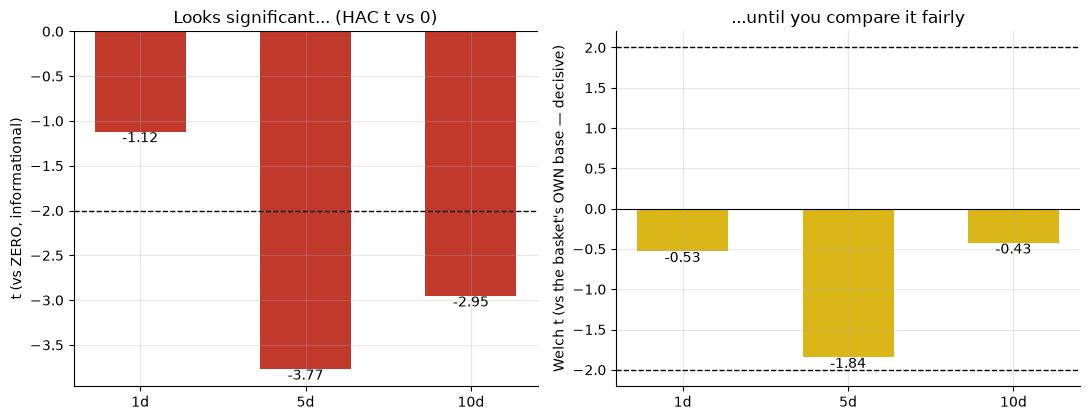

t vs zero (HAC): [-1.12, -3.77, -2.95]
t vs base (Welch, decisive): [-0.53, -1.84, -0.43]


In [2]:
hs = [1, 5, 10]
if HAVE_REAL:
    rows = [st.summarize(PANEL, h, placebo=False) for h in hs]
    means = [r['mean']*100 for r in rows]
    t_hac = [r['t_hac'] for r in rows]; t_welch = [r['t_welch'] for r in rows]
else:
    means = [R['h1'][2], R['h5'][2], R['h10'][2]]
    t_hac = [R['h1'][6], R['h5'][6], R['h10'][6]]
    t_welch = [R['h1'][8], R['h5'][8], R['h10'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.bar([f'{h}d' for h in hs], t_hac, color=RED, width=.55)
a1.axhline(-2, ls='--', c='k', lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('t (vs ZERO, informational)'); a1.set_title('Looks significant... (HAC t vs 0)')
for i,t in enumerate(t_hac): a1.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
a2.bar([f'{h}d' for h in hs], t_welch, color=AMBER, width=.55)
a2.axhline(-2, ls='--', c='k', lw=1); a2.axhline(2, ls='--', c='k', lw=1); a2.axhline(0, c='k', lw=.8)
a2.set_ylabel('Welch t (vs the basket\'s OWN base — decisive)'); a2.set_title('...until you compare it fairly')
for i,t in enumerate(t_welch): a2.annotate(f'{t:.2f}',(i,t),ha='center',va='top' if t<0 else 'bottom')
plt.tight_layout(); plt.show()
print('t vs zero (HAC):', [round(t,2) for t in t_hac])
print('t vs base (Welch, decisive):', [round(t,2) for t in t_welch])

> 💡 In plain words: the left panel — comparing to zero — clears the dashed **−2** bar at 5- and 10-day (-3.77, -2.95). Panic averted by the right panel: once compared to what the *same basket* earns on an **ordinary** day, none of the three horizons clear ±2 (-0.53, -1.84, -0.43). The left panel was measuring the market's up-drift, not the star. This is exactly why the Welch-vs-base number is the one on the front-card.

### 4b · The full inference table — HAC, one-sample, Welch, hit-rate, placebo

Every arbiter at once. The believer needs a **positive** signed-short excess over the base with Welch *t* ≥ +2; nothing here comes close.

In [3]:
import pandas as pd
if HAVE_REAL:
    tab = pd.DataFrame([st.summarize(PANEL, h, n_draws=5000) for h in hs])
    show = tab[['horizon','n_events','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net']].copy()
    for c in ['mean','base_mean','net']: show[c] = (show[c]*100).round(3)
    for c in ['hit','base_hit']: show[c] = (show[c]*100).round(0)
    for c in ['t_hac','t_one','t_welch']: show[c] = show[c].round(2)
    show['p_placebo'] = show['p_placebo'].round(3)
else:
    keys=['h1','h5','h10']
    cols=['horizon','n_events','mean','base_mean','hit','base_hit','t_hac','t_one','t_welch','p_placebo','net5','net10']
    show = pd.DataFrame([dict(zip(cols, R[k])) for k in keys]).drop(columns=['net10']).rename(columns={'net5':'net'})
print(show.to_string(index=False))

 horizon  n_events   mean  base_mean  hit  base_hit  t_hac  t_one  t_welch  p_placebo    net
       1       602 -0.055      0.028 50.0      48.0  -1.12  -1.09    -0.53      0.842 -0.157
       5       602 -0.527      0.252 44.0      45.0  -3.77  -3.55    -1.84      1.000 -0.637
      10       600 -0.612      0.529 46.0      43.0  -2.95  -3.14    -0.43      0.999 -0.732


> 💡 In plain words: the `hit`/`base_hit` columns are nearly identical (and the 10-day pattern day is even *slightly* more likely to be up than an ordinary day) — no directional tilt either way. `t_welch`, the decisive column, never leaves the noise band. The signed return is negative in absolute terms simply because shorting anything in this tape tends to lose to the market's own drift.

### 4c · Bonferroni across the basket — does one name secretly carry it?

A pooled null can hide a real effect concentrated in a handful of names, or manufacture a fake one from a single noisy outlier. Per-ticker Welch *t* (event sample vs that ticker's *own* unconditional pool — drift-neutral at the name level too) at $H=5$, with the Bonferroni-corrected bar for $k=30$ simultaneous tests.

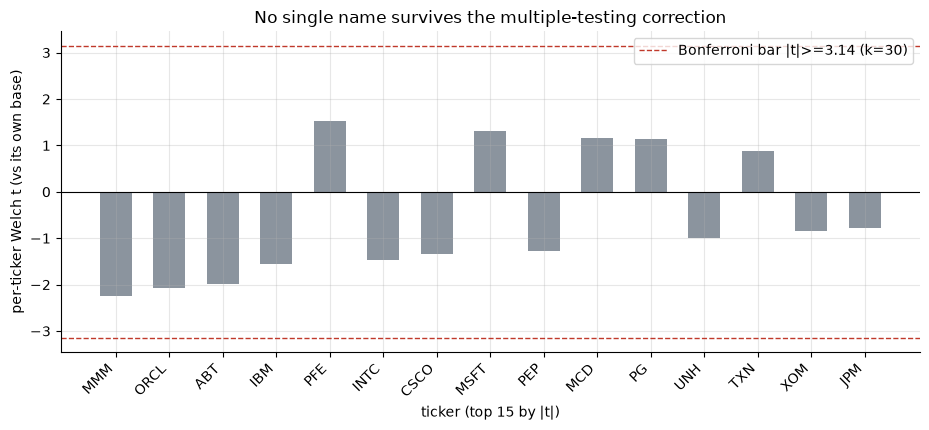

30 tickers tested, Bonferroni bar=3.14, survivors: 0


In [4]:
pt = st.per_ticker_stats(PANEL, 5) if HAVE_REAL else None
if pt is not None and len(pt):
    zc = st.bonferroni_z(len(pt))
    order = pt.reindex(pt['t_welch'].abs().sort_values(ascending=False).index)
    tickers = list(order['ticker']); tv = list(order['t_welch'])
    k = len(pt)
else:
    zc = R['bonf_z']; k = R['bonf_k']
    tickers = [b[0] for b in R['bonf_top']]; tv = [b[3] for b in R['bonf_top']]
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols = [RED if abs(t) >= zc else GREY for t in tv[:15]]
ax.bar(tickers[:15], tv[:15], color=cols, width=.6)
ax.axhline(zc, ls='--', c=RED, lw=1, label=f'Bonferroni bar |t|>={zc:.2f} (k={k})')
ax.axhline(-zc, ls='--', c=RED, lw=1)
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('per-ticker Welch t (vs its own base)'); ax.set_xlabel('ticker (top 15 by |t|)')
ax.set_title('No single name survives the multiple-testing correction')
plt.xticks(rotation=45, ha='right'); ax.legend(); plt.tight_layout(); plt.show()
print(f'{k} tickers tested, Bonferroni bar={zc:.2f}, survivors:', sum(abs(t)>=zc for t in tv))

> 💡 In plain words: even the loudest names in a 30-name basket — exactly the outliers a chart-reader would cherry-pick and show you — sit *below* the corrected bar (**0/30** clear it). The pooled null in 4a/4b isn't hiding a real effect in a handful of names; there's simply no name carrying it.

### 4d · The myth check — does a stricter star rescue it?

Two ways to make the signal "purer": the **strict textbook gap** (the star's body doesn't touch candle $t\!-\!2$'s body at all), and only counting stars that **followed a genuine prior uptrend** (a true reversal). If the lore were right, these should sharpen the effect.

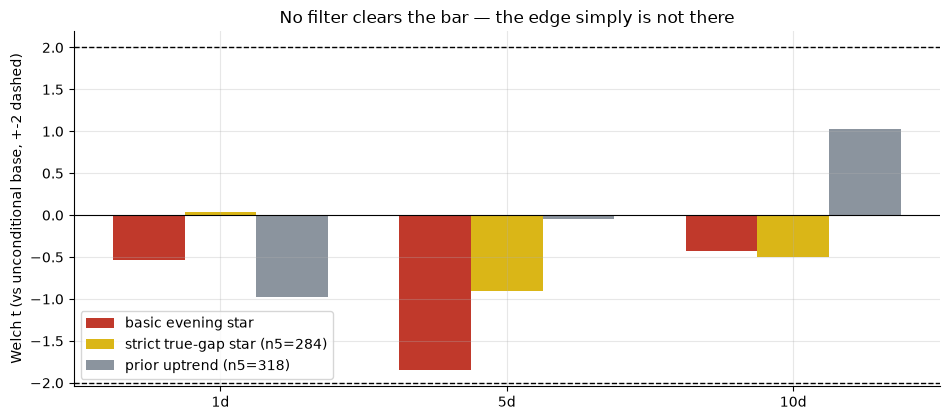

strict Welch t: [0.04, -0.91, -0.5]
trend Welch t : [-0.98, -0.05, 1.03]


In [5]:
if HAVE_REAL:
    basic  = [st.summarize(PANEL, h, placebo=False)['t_welch'] for h in hs]
    strict = [st.summarize(PANEL, h, placebo=False, gap_tol_frac=0.0)['t_welch'] for h in hs]
    trend  = [st.summarize(PANEL, h, placebo=False, require_trend=True)['t_welch'] for h in hs]
    ns = st.summarize(PANEL, 5, placebo=False, gap_tol_frac=0.0)['n_events']
    nt = st.summarize(PANEL, 5, placebo=False, require_trend=True)['n_events']
else:
    basic  = [R['h1'][8], R['h5'][8], R['h10'][8]]
    strict = [s[3] for s in R['strict']]; trend = [t[3] for t in R['trend']]
    ns = R['strict'][1][1]; nt = R['trend'][1][1]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(x-.25, basic, .25, color=RED, label='basic evening star')
ax.bar(x,      strict,.25, color=AMBER, label=f'strict true-gap star (n5={ns})')
ax.bar(x+.25,  trend, .25, color=GREY, label=f'prior uptrend (n5={nt})')
ax.axhline(2, ls='--', c='k', lw=1); ax.axhline(-2, ls='--', c='k', lw=1); ax.axhline(0,c='k',lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('Welch t (vs unconditional base, +-2 dashed)'); ax.set_title('No filter clears the bar — the edge simply is not there')
ax.legend(); plt.tight_layout(); plt.show()
print('strict Welch t:', [round(s,2) for s in strict]); print('trend Welch t :', [round(t,2) for t in trend])

> 💡 In plain words: the strict true-gap star (only **284** events at 5d — a smaller, rarer sample) gives Welch *t* = **-0.91**, and the prior-uptrend reversal gives *t* = **-0.05**. Both sit inside the noise band. The pattern's predictive content is **indistinguishable from the basket's own drift** under every reasonable definition.

### 4e · Costs — the loss only deepens

Gross vs net (5 / 10 bps one-way × 2 + 50 bps/yr borrow on the short). When the excess over base is already statistically nothing, costs can't save it — they bury the gross number.

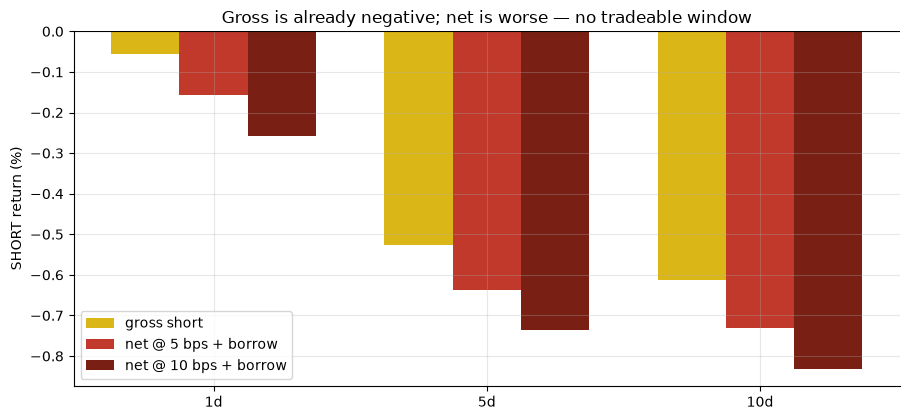

 1d: gross=-0.055%  net5bps=-0.157%  net10bps=-0.257%
 5d: gross=-0.527%  net5bps=-0.637%  net10bps=-0.737%
10d: gross=-0.612%  net5bps=-0.732%  net10bps=-0.832%


In [6]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [st.net_of_costs(st.summarize(PANEL, h, placebo=False)['mean'], h, cost_bps=5.0)*100 for h in hs]
    n10= [st.net_of_costs(st.summarize(PANEL, h, placebo=False)['mean'], h, cost_bps=10.0)*100 for h in hs]
else:
    g  = [R['h1'][2], R['h5'][2], R['h10'][2]]
    n5 = [R['h1'][10], R['h5'][10], R['h10'][10]]
    n10= [R['h1'][11], R['h5'][11], R['h10'][11]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.25, g, .25, color=AMBER, label='gross short')
ax.bar(x,      n5, .25, color=RED, label='net @ 5 bps + borrow')
ax.bar(x+.25,  n10,.25, color='#7a1f14', label='net @ 10 bps + borrow')
ax.axhline(0,c='k',lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('SHORT return (%)'); ax.set_title('Gross is already negative; net is worse — no tradeable window')
ax.legend(); plt.tight_layout(); plt.show()
for h,gg,n5_,n10_ in zip(hs,g,n5,n10): print(f'{h:>2}d: gross={gg:+.3f}%  net5bps={n5_:+.3f}%  net10bps={n10_:+.3f}%')

> 💡 In plain words: at 5 days gross **-0.53%** → net **-0.64%** (5 bps) / **-0.74%** (10 bps). There is no horizon where the short clears zero, let alone its costs, let alone the unconditional base it should be beating. **Mirage** in the strict sense — nothing under it to charge costs *against*.

### 4f · Faithful-engine & power control — the drift trap, proven on a KNOWN-zero panel

A deterministic panel with its own mild embedded up-drift (so tall-up-candle stars actually occur — mirroring the real basket's contamination risk) and a **planted** post-pattern crash knob. With **zero** planted edge, the certifying **Welch t** (vs the panel's own base) must stay inside ±2 across **20 independent seeds**; the one-sample *t*-vs-zero, by contrast, is shown to fire on its own from the embedded drift alone — exactly the trap in 4a.

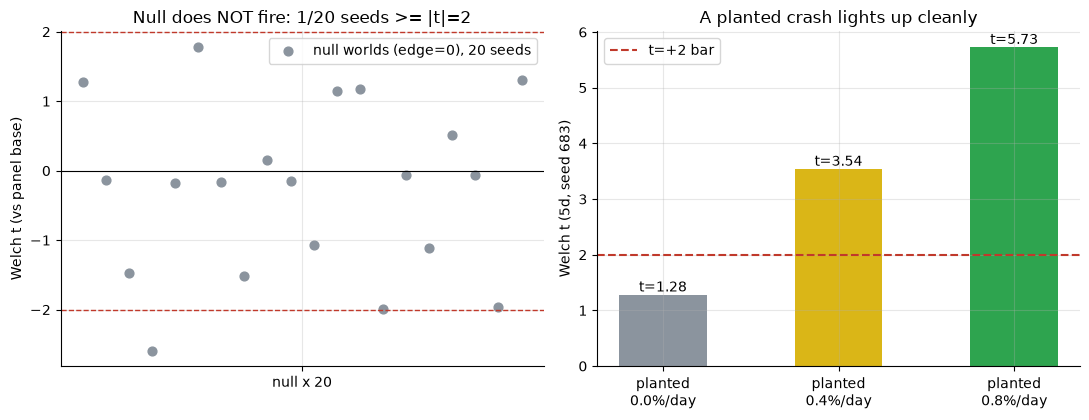

null Welch t: mean=-0.26 sd=1.25 |t|>=2 in 1/20
planted +0.0%/day: n=358 mean=-0.007% t_welch=1.28 t_hac(vs0)=-0.04 p=0.524 hit=47%
planted +0.4%/day: n=358 mean=+0.397% t_welch=3.54 t_hac(vs0)=2.43 p=0.011 hit=53%
planted +0.8%/day: n=357 mean=+0.787% t_welch=5.73 t_hac(vs0)=4.82 p=0.000 hit=61%


In [7]:
null_welch = []
for s_ in range(20):
    px, _ = data.synthetic_panel(edge=0.0, seed=683 + s_)
    null_welch.append(st.summarize(px, 5, placebo=False)['t_welch'])
null_welch = np.asarray(null_welch)
res = []
for edge in (0.0, 0.004, 0.008):
    px, truth = data.synthetic_panel(edge=edge, seed=683)
    s = st.summarize(px, 5, n_draws=4000)
    res.append((edge, truth['n_planted_days'], s['n_events'], s['mean']*100, s['t_welch'], s['t_hac'], s['p_placebo'], s['hit']*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.3))
a1.scatter(np.zeros(20) + np.linspace(-.1,.1,20), null_welch, color=GREY, s=40, label='null worlds (edge=0), 20 seeds')
a1.axhline(-2, ls='--', c=RED, lw=1); a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_xticks([0]); a1.set_xticklabels(['null x 20']); a1.set_ylabel('Welch t (vs panel base)')
a1.set_title(f'Null does NOT fire: {int((abs(null_welch)>=2).sum())}/20 seeds >= |t|=2'); a1.legend()
labels = [f'planted\n{e*100:.1f}%/day' for e,_,_,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
a2.bar(labels, tvals, color=[GREY, AMBER, GREEN], width=.5)
a2.axhline(2, ls='--', c=RED, label='t=+2 bar')
for i,t in enumerate(tvals): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
a2.set_ylabel('Welch t (5d, seed 683)'); a2.set_title('A planted crash lights up cleanly'); a2.legend()
plt.tight_layout(); plt.show()
print(f'null Welch t: mean={null_welch.mean():+.2f} sd={null_welch.std(ddof=1):.2f} |t|>=2 in {(abs(null_welch)>=2).sum()}/20')
for e,pd_,k,ls,tw,th,p,w in res: print(f'planted {e*100:+.1f}%/day: n={k} mean={ls:+.3f}% t_welch={tw:.2f} t_hac(vs0)={th:.2f} p={p:.3f} hit={w:.0f}%')

> 💡 In plain words: with **no** planted crash, the certifying Welch *t* averages **-0.26** (sd 1.25) across 20 seeds and fires in only **1/20** — in line with the ~5% nominal false-positive rate of a two-sigma bar, not a systematic bias. A planted crash of 0.4%/day reaches Welch *t* = **3.54**, and 0.8%/day reaches **5.73** — the harness *would* catch a real evening-star crash if one existed. Note also the null-world's *own* vs-zero HAC *t* (-0.04) — even with **zero** planted edge, a naive read isn't always innocent either, which is exactly why Welch-vs-base is the number that decides the verdict, not HAC-vs-zero.

## 5 · The verdict

- **Signal `NONE`** — the certifying, drift-neutral Welch *t* (event sample vs the basket's own unconditional forward return) never reaches **\|t\| >= 2** at any horizon (-0.53 / -1.84 / -0.43 for 1/5/10 days). Hit rates track the base rate. The coin-flip placebo places the observed mean where 84-100% of random draws would have matched or beaten it. **0/30** tickers survive a Bonferroni correction individually. Neither a strict textbook gap nor a genuine prior-uptrend filter rescues it. Carries an explicit **survivorship** caveat that tilts the test *toward* the claim — and it still fails. NONE, not WEAK.
- **Tradability `MIRAGE`** — negative **gross** at every horizon (-0.06% to -0.61%); net of a round-trip cost + short borrow it's worse across the whole 5-10 bps sweep (-0.64% to -0.83%). There is no edge to charge costs against.
- **Crash incoming? `BUSTED`** — the "top of the uptrend, sell now" reading does not survive a fair comparison to what the same basket does on an ordinary day. Neither purity filter saves it, and no individual name in the basket carries a Bonferroni-robust version of the story.

## 6 · Could you trade it? — the only money is in fading the lore

One picture for the operational truth: the signed-**short** net return by horizon against the break-even line and against what an ordinary day earns on the same bet. The "tradeable" region — net above *both* zero and the baseline — is **empty**.

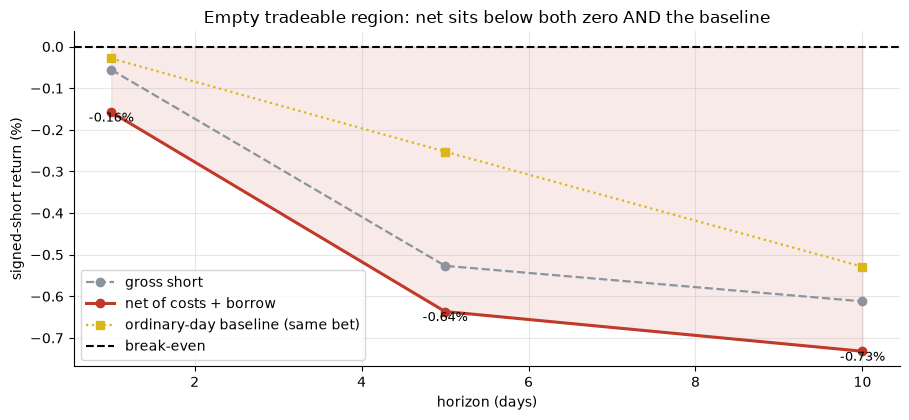

net short by horizon: {'1d': -0.157, '5d': -0.637, '10d': -0.732}


In [8]:
if HAVE_REAL:
    g  = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    n5 = [st.net_of_costs(st.summarize(PANEL, h, placebo=False)['mean'], h, cost_bps=5.0)*100 for h in hs]
    base = [-st.summarize(PANEL, h, placebo=False)['base_mean']*100 for h in hs]
else:
    g  = [R['h1'][2], R['h5'][2], R['h10'][2]]
    n5 = [R['h1'][10], R['h5'][10], R['h10'][10]]
    base = [-R['h1'][3], -R['h5'][3], -R['h10'][3]]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.plot(hs, g, 'o--', c=GREY, lw=1.6, label='gross short')
ax.plot(hs, n5, 'o-', c=RED, lw=2.2, label='net of costs + borrow')
ax.plot(hs, base, 's:', c=AMBER, lw=1.6, label='ordinary-day baseline (same bet)')
ax.axhline(0, c='k', ls='--', label='break-even')
ax.fill_between(hs, 0, n5, color=RED, alpha=.10)
for h,v in zip(hs,n5): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('signed-short return (%)')
ax.set_title('Empty tradeable region: net sits below both zero AND the baseline'); ax.legend()
plt.tight_layout(); plt.show()
print('net short by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,n5)})

> 💡 In plain words: the red (net) line sits below **both** zero and the amber baseline at every horizon — there is no window where shorting the star pays, and no window where it even beats doing nothing special. The contrarian residue (the stock drifting up) is just the unconditional equity drift you'd capture by holding *anything*; it is not a pattern edge and carries no timing value. Hence **Mirage**, and the bearish claim is **Busted**.

## 7 · Going further

- **Why it fails, mechanically.** The confirming candle is, by construction, a stock that just had a sharp **down** day; short-horizon mean reversion (the bounce) works against a fresh short, and the naive vs-zero test simply rediscovers the market's own up-drift — a trap this study's Welch-vs-base design is built to avoid.
- **The survivorship lever points the *right* way here.** Excluding delisted, actually-crashed names biases us **toward** a working short signal — so a clean fail on survivors is strong evidence. Marshall, Young & Rose (2006) reach the same broad null on the DJIA cross-section.
- **The bullish mirror & near neighbours.** [186-morning-star](../../186-morning-star/) tests the buy-side twin (different harness, same conclusion); [408-three-black-crows](../../408-three-black-crows/) is a structurally different three-red-candle pattern sharing the same mean-reversion headwind; [404-shooting-star](../../404-shooting-star/) is a single-candle relative;
  [402-engulfing-pattern](../../402-engulfing-pattern/) is a two-candle relative.

*The reproducible core is offline and deterministic; the detector is the precise real-body evening star with a strict-gap variant and a prior-uptrend filter as myth-checks, and a Bonferroni correction across the 30-name basket. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*